# QAOA Circuit Transpilation

## QAOA Circuit

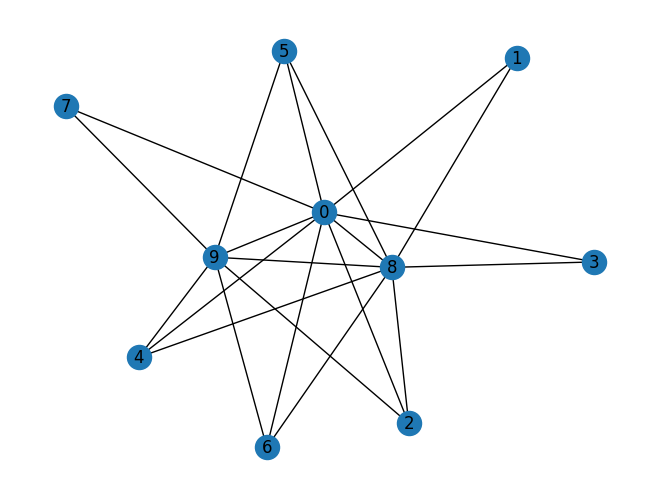

In [23]:
from networkx import barabasi_albert_graph, draw

graph = barabasi_albert_graph(n=10, m=7, seed=42)
draw(graph, with_labels=True)

In [24]:
from utils import build_max_cut_paulis
from qiskit.quantum_info import SparsePauliOp

local_correlators = build_max_cut_paulis(graph)
cost_operator = SparsePauliOp.from_list(local_correlators)
print(cost_operator)

SparsePauliOp(['IIIIIIIIZZ', 'IIIIIIIZIZ', 'IIIIIIZIIZ', 'IIIIIZIIIZ', 'IIIIZIIIIZ', 'IIIZIIIIIZ', 'IIZIIIIIIZ', 'IZIIIIIIIZ', 'ZIIIIIIIIZ', 'IZIIIIIIZI', 'IZIIIIIZII', 'ZIIIIIIZII', 'IZIIIIZIII', 'IZIIIZIIII', 'ZIIIIZIIII', 'IZIIZIIIII', 'ZIIIZIIIII', 'IZIZIIIIII', 'ZIIZIIIIII', 'ZIZIIIIIII', 'ZZIIIIIIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j])


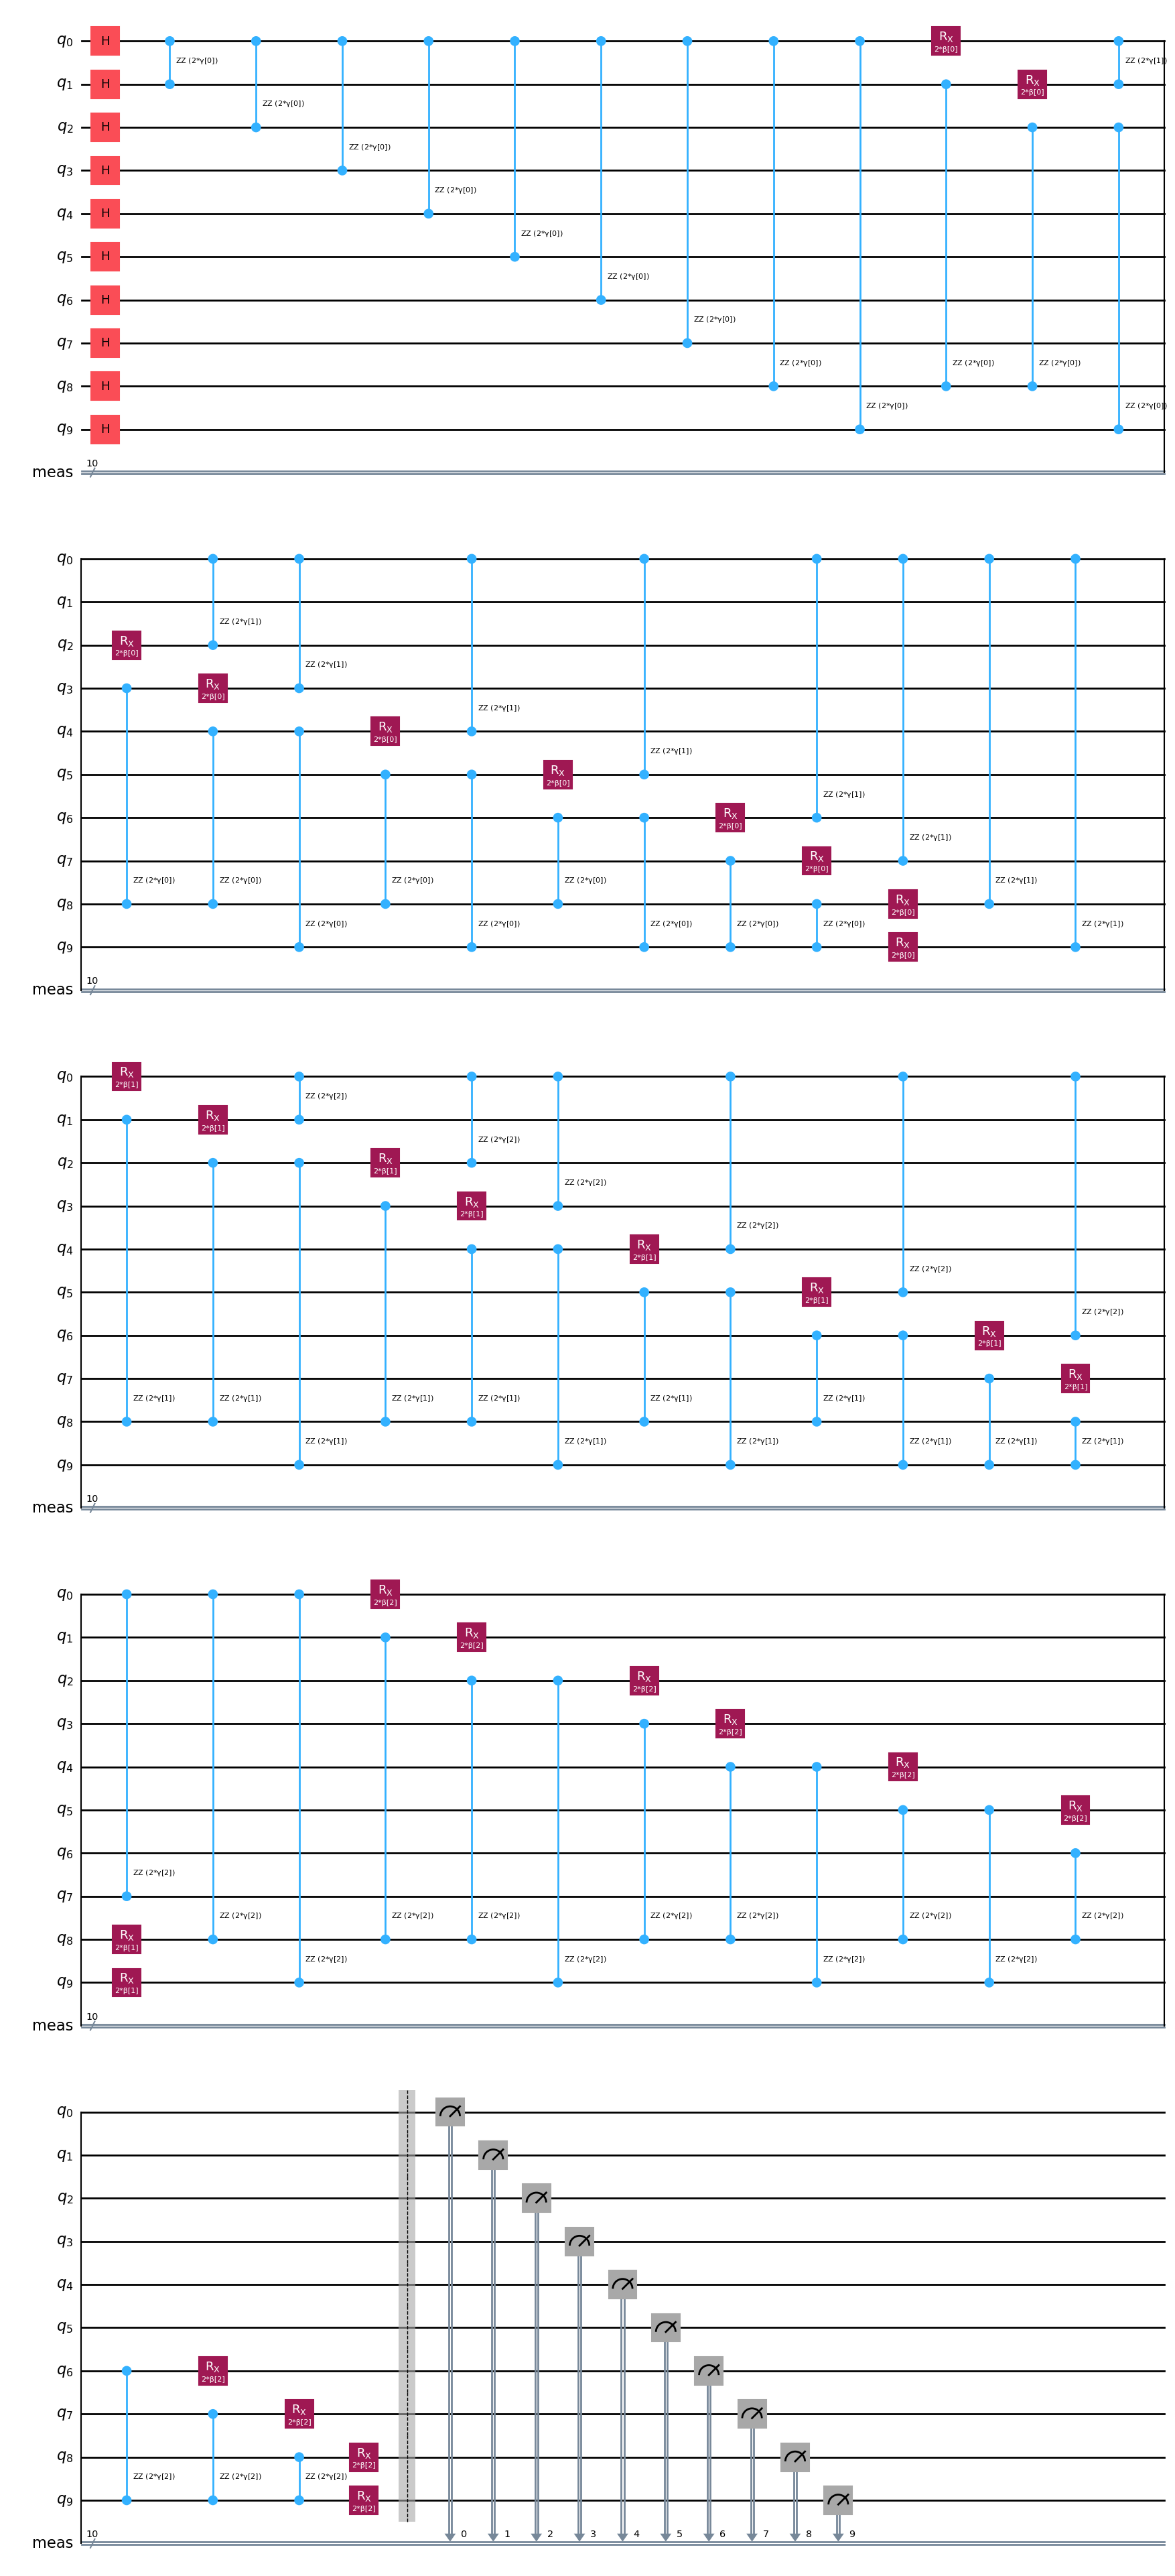

In [25]:
from qiskit.circuit.library import qaoa_ansatz

num_qubits = cost_operator.num_qubits
qaoa_circuit = qaoa_ansatz(cost_operator, reps=3)
qaoa_circuit.measure_all()
qaoa_circuit.draw("mpl")

## QPU

In [26]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
service.backends()

[<IBMBackend('ibm_boston')>,
 <IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_pittsburgh')>,
 <IBMBackend('ibm_kingston')>,
 <IBMBackend('ibm_miami')>,
 <IBMBackend('ibm_marrakesh')>]

In [27]:
# backend = service.backend("ibm_pittsburgh")
backend = service.backend("ibm_pittsburgh", use_fractional_gates=True)

## Qiskit Transpiler

In [28]:
# Pre-transpilation circuit
print(qaoa_circuit.count_ops())

OrderedDict({'rzz': 63, 'rx': 30, 'h': 10, 'measure': 10, 'barrier': 1})


In [29]:
import time
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Generate a preset pass manager for transpilation

pm_opt_lvl_0 = generate_preset_pass_manager(optimization_level=0, backend=backend)
pm_opt_lvl_1 = generate_preset_pass_manager(optimization_level=1, backend=backend)
pm_opt_lvl_2 = generate_preset_pass_manager(optimization_level=2, backend=backend)
pm_opt_lvl_3 = generate_preset_pass_manager(optimization_level=3, backend=backend)

# Optimization level 0
t0 = time.time()
transpiled_qaoa_opt_lvl_0 = pm_opt_lvl_0.run(qaoa_circuit)
t1 = time.time()
t_opt_lvl_0 = t1 - t0
# Print the total transpilation time
print(f"Transpilation time with optimization level 0: {t_opt_lvl_0:.2f} (s)")

# Optimization level 1
t0 = time.time()
transpiled_qaoa_opt_lvl_1 = pm_opt_lvl_1.run(qaoa_circuit)
t1 = time.time()
t_opt_lvl_1 = t1 - t0
print(f"Transpilation time with optimization level 1: {t_opt_lvl_1:.2f} (s)")

# Optimization level 2
t0 = time.time()
transpiled_qaoa_opt_lvl_2 = pm_opt_lvl_2.run(qaoa_circuit)
t1 = time.time()
t_opt_lvl_2 = t1 - t0
print(f"Transpilation time with optimization level 2: {t_opt_lvl_2:.2f} (s)")

# Optimization level 3
t0 = time.time()
transpiled_qaoa_opt_lvl_3 = pm_opt_lvl_3.run(qaoa_circuit)
t1 = time.time()
t_opt_lvl_3 = t1 - t0
print(f"Transpilation time with optimization level 3: {t_opt_lvl_3:.2f} (s)")

Transpilation time with optimization level 0: 0.01 (s)
Transpilation time with optimization level 1: 0.02 (s)
Transpilation time with optimization level 2: 0.03 (s)
Transpilation time with optimization level 3: 0.05 (s)


In [30]:
from utils import extract_circuit_metrics

metrics_opt_lvl_0 = extract_circuit_metrics(transpiled_qaoa_opt_lvl_0)
metrics_opt_lvl_1 = extract_circuit_metrics(transpiled_qaoa_opt_lvl_1)
metrics_opt_lvl_2 = extract_circuit_metrics(transpiled_qaoa_opt_lvl_2)
metrics_opt_lvl_3 = extract_circuit_metrics(transpiled_qaoa_opt_lvl_3)

# Print the metrics for each optimization level
print("\nMetrics for optimization level 0:")
for key, value in metrics_opt_lvl_0.items():
    print(f"{key}: {value}")
print("\nMetrics for optimization level 1:")
for key, value in metrics_opt_lvl_1.items():
    print(f"{key}: {value}")
print("\nMetrics for optimization level 2:")
for key, value in metrics_opt_lvl_2.items():
    print(f"{key}: {value}")
print("\nMetrics for optimization level 3:")
for key, value in metrics_opt_lvl_3.items():
    print(f"{key}: {value}")


Metrics for optimization level 0:
count_ops: OrderedDict({'sx': 802, 'cz': 396, 'rzz': 63, 'rx': 30, 'rz': 20, 'measure': 10, 'barrier': 1})
depth: 497
two_qubit_gates: 459
two_qubit_gate_depth: 259

Metrics for optimization level 1:
count_ops: OrderedDict({'sx': 390, 'cz': 195, 'rzz': 63, 'rx': 35, 'rz': 15, 'measure': 10, 'barrier': 1})
depth: 326
two_qubit_gates: 258
two_qubit_gate_depth: 175

Metrics for optimization level 2:
count_ops: OrderedDict({'sx': 380, 'cz': 189, 'rzz': 63, 'rx': 34, 'rz': 16, 'measure': 10, 'barrier': 1})
depth: 319
two_qubit_gates: 252
two_qubit_gate_depth: 168

Metrics for optimization level 3:
count_ops: OrderedDict({'sx': 378, 'cz': 189, 'rzz': 63, 'rx': 35, 'rz': 15, 'measure': 10, 'barrier': 1})
depth: 282
two_qubit_gates: 252
two_qubit_gate_depth: 152


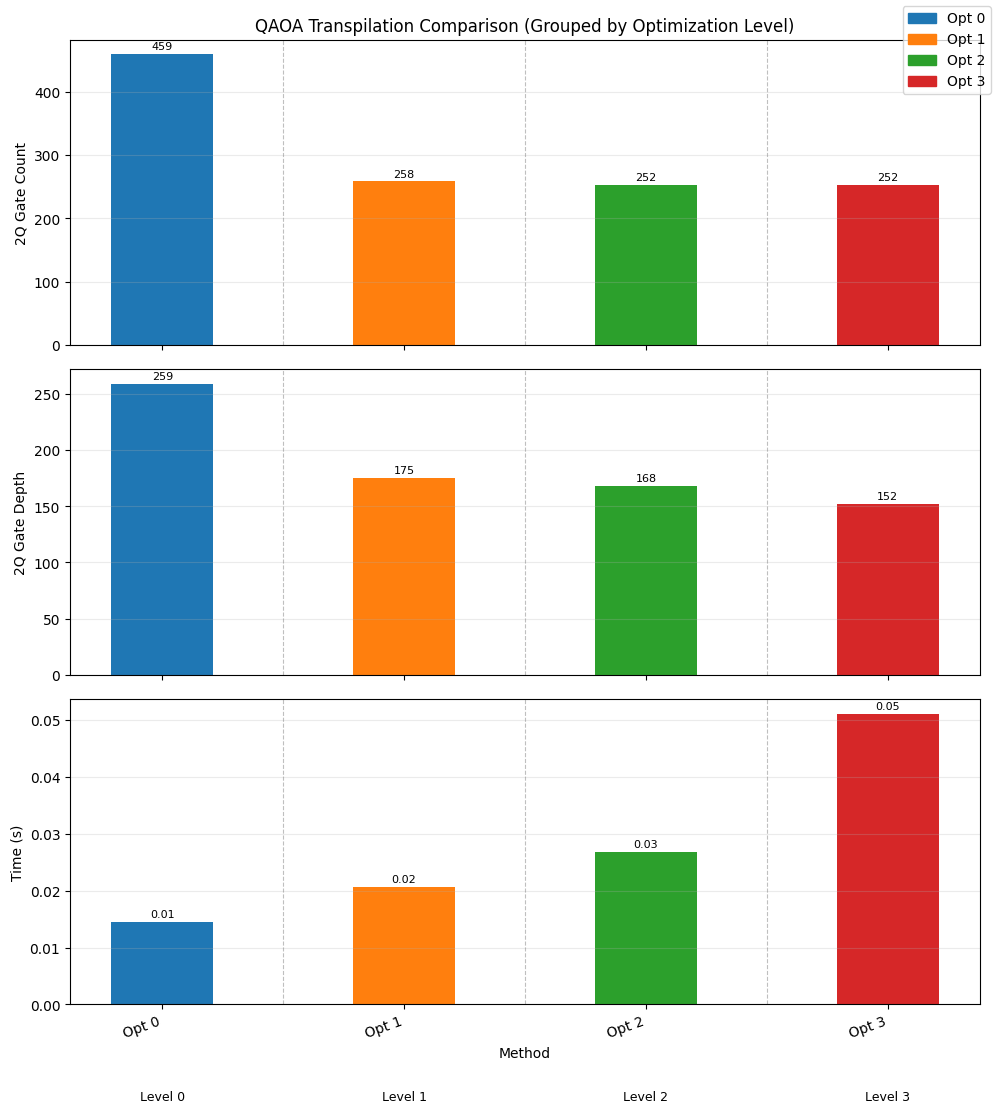

In [31]:
# Plot metrics comparison in 3 vertical panels (grouped by optimization level)
import matplotlib.pyplot as plt

# First plot uses only baseline transpiler outputs (best-seed data not available yet)
groups = [
    [('Opt 0', metrics_opt_lvl_0, t_opt_lvl_0, '#1f77b4')],
    [('Opt 1', metrics_opt_lvl_1, t_opt_lvl_1, '#ff7f0e')],
    [('Opt 2', metrics_opt_lvl_2, t_opt_lvl_2, '#2ca02c')],
    [('Opt 3', metrics_opt_lvl_3, t_opt_lvl_3, '#d62728')],
]

x_positions = []
method_labels = []
method_colors = []
twoq_counts = []
twoq_depths = []
transpile_times = []
group_centers = []
group_boundaries = []

current_x = 0.0
within_group_step = 1.0
group_gap = 0.9

for group in groups:
    start_x = current_x
    for label, metrics, t_val, color in group:
        x_positions.append(current_x)
        method_labels.append(label)
        method_colors.append(color)
        twoq_counts.append(metrics['two_qubit_gates'])
        twoq_depths.append(metrics['two_qubit_gate_depth'])
        transpile_times.append(t_val)
        current_x += within_group_step
    end_x = current_x - within_group_step
    group_centers.append((start_x + end_x) / 2)
    group_boundaries.append(current_x - within_group_step / 2 + group_gap / 2)
    current_x += group_gap

fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)

series = [twoq_counts, twoq_depths, transpile_times]
ylabels = ['2Q Gate Count', '2Q Gate Depth', 'Time (s)']
label_formatters = [
    lambda v: str(int(v)),
    lambda v: str(int(v)),
    lambda v: f'{v:.2f}',
]

for ax, values, ylabel, fmt in zip(axes, series, ylabels, label_formatters):
    bars = ax.bar(x_positions, values, color=method_colors, width=0.8)
    ax.set_ylabel(ylabel)
    ax.bar_label(bars, labels=[fmt(v) for v in values], padding=2, fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    for boundary in group_boundaries[:-1]:
        ax.axvline(boundary, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

axes[0].set_title('QAOA Transpilation Comparison (Grouped by Optimization Level)')
axes[2].set_xlabel('Method')
axes[2].set_xticks(x_positions)
axes[2].set_xticklabels(method_labels, rotation=20, ha='right')

for i, center in enumerate(group_centers):
    axes[2].text(center, -0.28, f'Level {i}', transform=axes[2].get_xaxis_transform(), ha='center', va='top', fontsize=9)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=l) for c, l in zip(method_colors, method_labels)]
fig.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()

## Qiskit Transpiler + Transpile Multiple Times

In [32]:
import time

depth = 2000

t0 = time.time()
for seed in range(0,100):
    pm_opt_lvl_1_optimized_seed = generate_preset_pass_manager(optimization_level=1, backend=backend, seed_transpiler=seed)
    transpiled_qaoa = pm_opt_lvl_1_optimized_seed.run(qaoa_circuit)
    current_depth = transpiled_qaoa.depth(lambda x: x.operation.num_qubits == 2)
    if current_depth < depth:
        depth = current_depth
        best_circuit = transpiled_qaoa
        seed_selected = seed
t1 = time.time()
print(f'Seed selected: {seed_selected}')
circuit = best_circuit
t_opt_lvl_1_optimized_seed = t1 - t0
print(f"Transpilation time: {t_opt_lvl_1_optimized_seed} (s)")

metrics_opt_lvl_1_optimized_seed = extract_circuit_metrics(circuit)
print("\nMetrics for optimized seed transpilation:")
for key, value in metrics_opt_lvl_1_optimized_seed.items():
    print(f"{key}: {value}")

Seed selected: 48
Transpilation time: 1.816532850265503 (s)

Metrics for optimized seed transpilation:
count_ops: OrderedDict({'sx': 362, 'cz': 180, 'rzz': 63, 'rx': 34, 'rz': 16, 'measure': 10, 'barrier': 1})
depth: 255
two_qubit_gates: 243
two_qubit_gate_depth: 141


In [33]:
import time

depth = 2000

t0 = time.time()
for seed in range(0,100):
    pm_opt_lvl_2_optimized_seed = generate_preset_pass_manager(optimization_level=2, backend=backend, seed_transpiler=seed)
    transpiled_qaoa = pm_opt_lvl_2_optimized_seed.run(qaoa_circuit)
    current_depth = transpiled_qaoa.depth(lambda x: x.operation.num_qubits == 2)
    if current_depth < depth:
        depth = current_depth
        best_circuit = transpiled_qaoa
        seed_selected = seed
t1 = time.time()
print(f'Seed selected: {seed_selected}')
circuit = best_circuit
t_opt_lvl_2_optimized_seed = t1 - t0
print(f"Transpilation time: {t_opt_lvl_2_optimized_seed} (s)")

metrics_opt_lvl_2_optimized_seed = extract_circuit_metrics(circuit)
print("\nMetrics for optimized seed transpilation:")
for key, value in metrics_opt_lvl_2_optimized_seed.items():
    print(f"{key}: {value}")

Seed selected: 7
Transpilation time: 3.3432230949401855 (s)

Metrics for optimized seed transpilation:
count_ops: OrderedDict({'sx': 364, 'cz': 183, 'rzz': 63, 'rx': 36, 'rz': 14, 'measure': 10, 'barrier': 1})
depth: 258
two_qubit_gates: 246
two_qubit_gate_depth: 140


In [34]:
import time

depth = 2000

t0 = time.time()
for seed in range(0,100):
    pm_opt_lvl_3_optimized_seed = generate_preset_pass_manager(optimization_level=3, backend=backend, seed_transpiler=seed)
    transpiled_qaoa = pm_opt_lvl_3_optimized_seed.run(qaoa_circuit)
    current_depth = transpiled_qaoa.depth(lambda x: x.operation.num_qubits == 2)
    if current_depth < depth:
        depth = current_depth
        best_circuit = transpiled_qaoa
        seed_selected = seed
t1 = time.time()
print(f'Seed selected: {seed_selected}')
circuit = best_circuit
t_opt_lvl_3_optimized_seed = t1 - t0
print(f"Transpilation time: {t_opt_lvl_3_optimized_seed} (s)")

metrics_opt_lvl_3_optimized_seed = extract_circuit_metrics(circuit)
print("\nMetrics for optimized seed transpilation:")
for key, value in metrics_opt_lvl_3_optimized_seed.items():
    print(f"{key}: {value}")

Seed selected: 7
Transpilation time: 7.026074171066284 (s)

Metrics for optimized seed transpilation:
count_ops: OrderedDict({'sx': 364, 'cz': 183, 'rzz': 63, 'rx': 36, 'rz': 14, 'measure': 10, 'barrier': 1})
depth: 258
two_qubit_gates: 246
two_qubit_gate_depth: 140


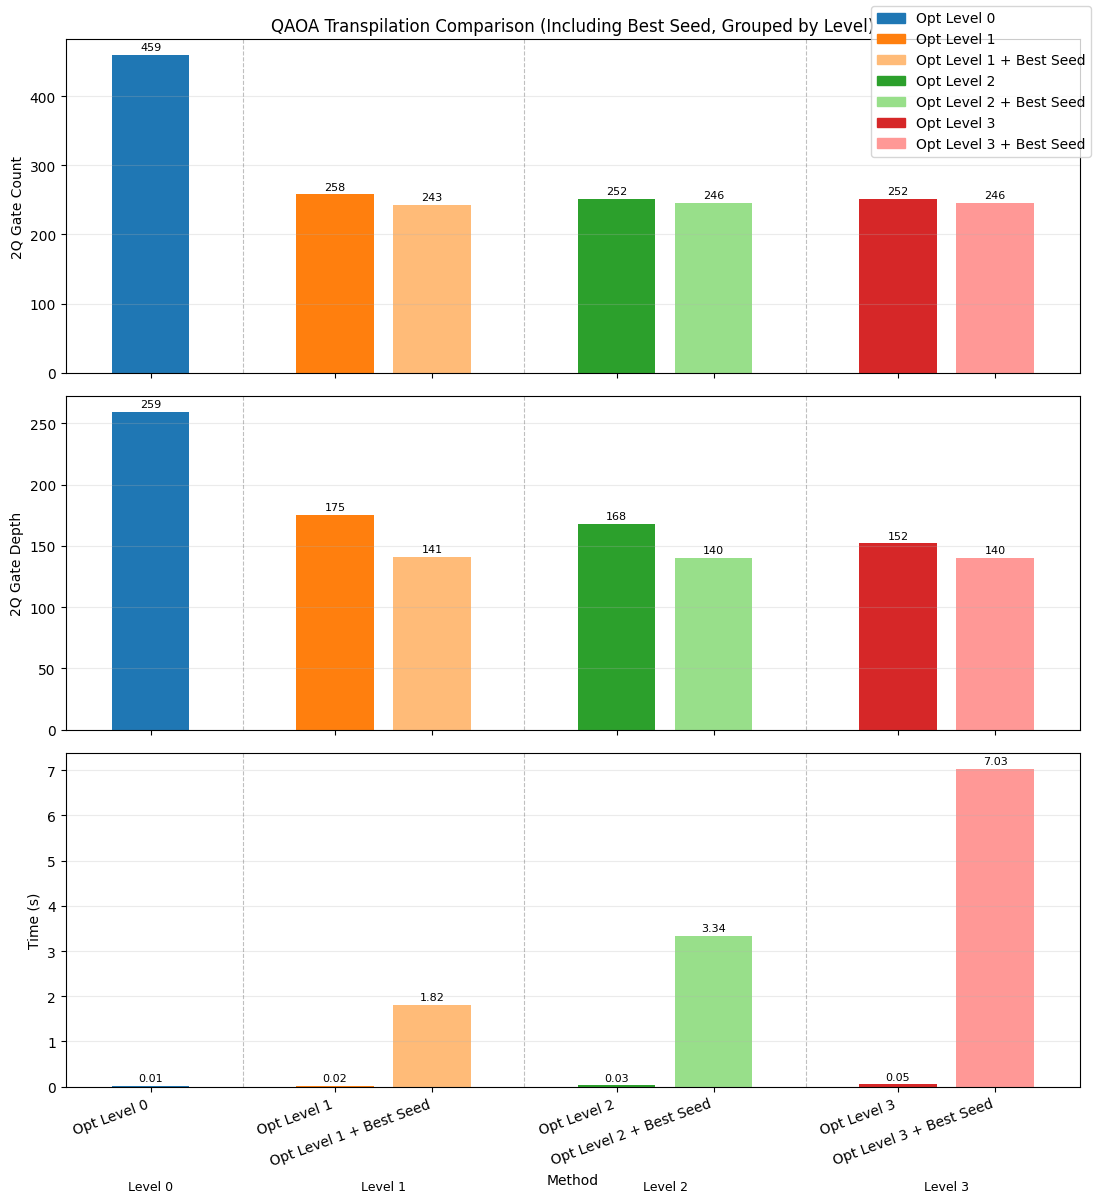

In [35]:
# Plot metrics comparison in 3 vertical panels (including optimized seed, grouped by level)
import matplotlib.pyplot as plt

groups = [
    [('Opt Level 0', metrics_opt_lvl_0, t_opt_lvl_0, '#1f77b4')],
    [('Opt Level 1', metrics_opt_lvl_1, t_opt_lvl_1, '#ff7f0e'), ('Opt Level 1 + Best Seed', metrics_opt_lvl_1_optimized_seed, t_opt_lvl_1_optimized_seed, '#ffbb78')],
    [('Opt Level 2', metrics_opt_lvl_2, t_opt_lvl_2, '#2ca02c'), ('Opt Level 2 + Best Seed', metrics_opt_lvl_2_optimized_seed, t_opt_lvl_2_optimized_seed, '#98df8a')],
    [('Opt Level 3', metrics_opt_lvl_3, t_opt_lvl_3, '#d62728'), ('Opt Level 3 + Best Seed', metrics_opt_lvl_3_optimized_seed, t_opt_lvl_3_optimized_seed, '#ff9896')],
]

x_positions = []
method_labels = []
method_colors = []
twoq_counts = []
twoq_depths = []
transpile_times = []
group_centers = []
group_boundaries = []

current_x = 0.0
within_group_step = 1.0
group_gap = 0.9

for group in groups:
    start_x = current_x
    for label, metrics, t_val, color in group:
        x_positions.append(current_x)
        method_labels.append(label)
        method_colors.append(color)
        twoq_counts.append(metrics['two_qubit_gates'])
        twoq_depths.append(metrics['two_qubit_gate_depth'])
        transpile_times.append(t_val)
        current_x += within_group_step
    end_x = current_x - within_group_step
    group_centers.append((start_x + end_x) / 2)
    group_boundaries.append(current_x - within_group_step / 2 + group_gap / 2)
    current_x += group_gap

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)

series = [twoq_counts, twoq_depths, transpile_times]
ylabels = ['2Q Gate Count', '2Q Gate Depth', 'Time (s)']
label_formatters = [
    lambda v: str(int(v)),
    lambda v: str(int(v)),
    lambda v: f'{v:.2f}',
]

for ax, values, ylabel, fmt in zip(axes, series, ylabels, label_formatters):
    bars = ax.bar(x_positions, values, color=method_colors, width=0.8)
    ax.set_ylabel(ylabel)
    ax.bar_label(bars, labels=[fmt(v) for v in values], padding=2, fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    for boundary in group_boundaries[:-1]:
        ax.axvline(boundary, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

axes[0].set_title('QAOA Transpilation Comparison (Including Best Seed, Grouped by Level)')
axes[2].set_xlabel('Method')
axes[2].set_xticks(x_positions)
axes[2].set_xticklabels(method_labels, rotation=20, ha='right')

for i, center in enumerate(group_centers):
    axes[2].text(center, -0.28, f'Level {i}', transform=axes[2].get_xaxis_transform(), ha='center', va='top', fontsize=9)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=l) for c, l in zip(method_colors, method_labels)]
fig.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()

## Qiskit AI Transpiler

In [36]:
from qiskit_ibm_transpiler import generate_ai_pass_manager

pm_ai_opt_lvl_1 = generate_ai_pass_manager(optimization_level=1, ai_optimization_level=1, backend=backend)
pm_ai_opt_lvl_2 = generate_ai_pass_manager(optimization_level=2, ai_optimization_level=2, backend=backend)
pm_ai_opt_lvl_3 = generate_ai_pass_manager(optimization_level=3, ai_optimization_level=3, backend=backend)

# Optimization level 1
t0 = time.time()
transpiled_qaoa_ai_opt_lvl_1 = pm_ai_opt_lvl_1.run(qaoa_circuit)
t1 = time.time()
t_ai_opt_lvl_1 = t1 - t0
print(f"Transpilation time with AI optimization level 1: {t_ai_opt_lvl_1:.2f} (s)")

# Optimization level 2
t0 = time.time()
transpiled_qaoa_ai_opt_lvl_2 = pm_ai_opt_lvl_2.run(qaoa_circuit)
t1 = time.time()
t_ai_opt_lvl_2 = t1 - t0
print(f"Transpilation time with AI optimization level 2: {t_ai_opt_lvl_2:.2f} (s)")

# Optimization level 3
t0 = time.time()
transpiled_qaoa_ai_opt_lvl_3 = pm_ai_opt_lvl_3.run(qaoa_circuit)
t1 = time.time()
t_ai_opt_lvl_3 = t1 - t0
print(f"Transpilation time with AI optimization level 3: {t_ai_opt_lvl_3:.2f} (s)")

Transpilation time with AI optimization level 1: 0.05 (s)
Transpilation time with AI optimization level 2: 0.41 (s)
Transpilation time with AI optimization level 3: 0.90 (s)


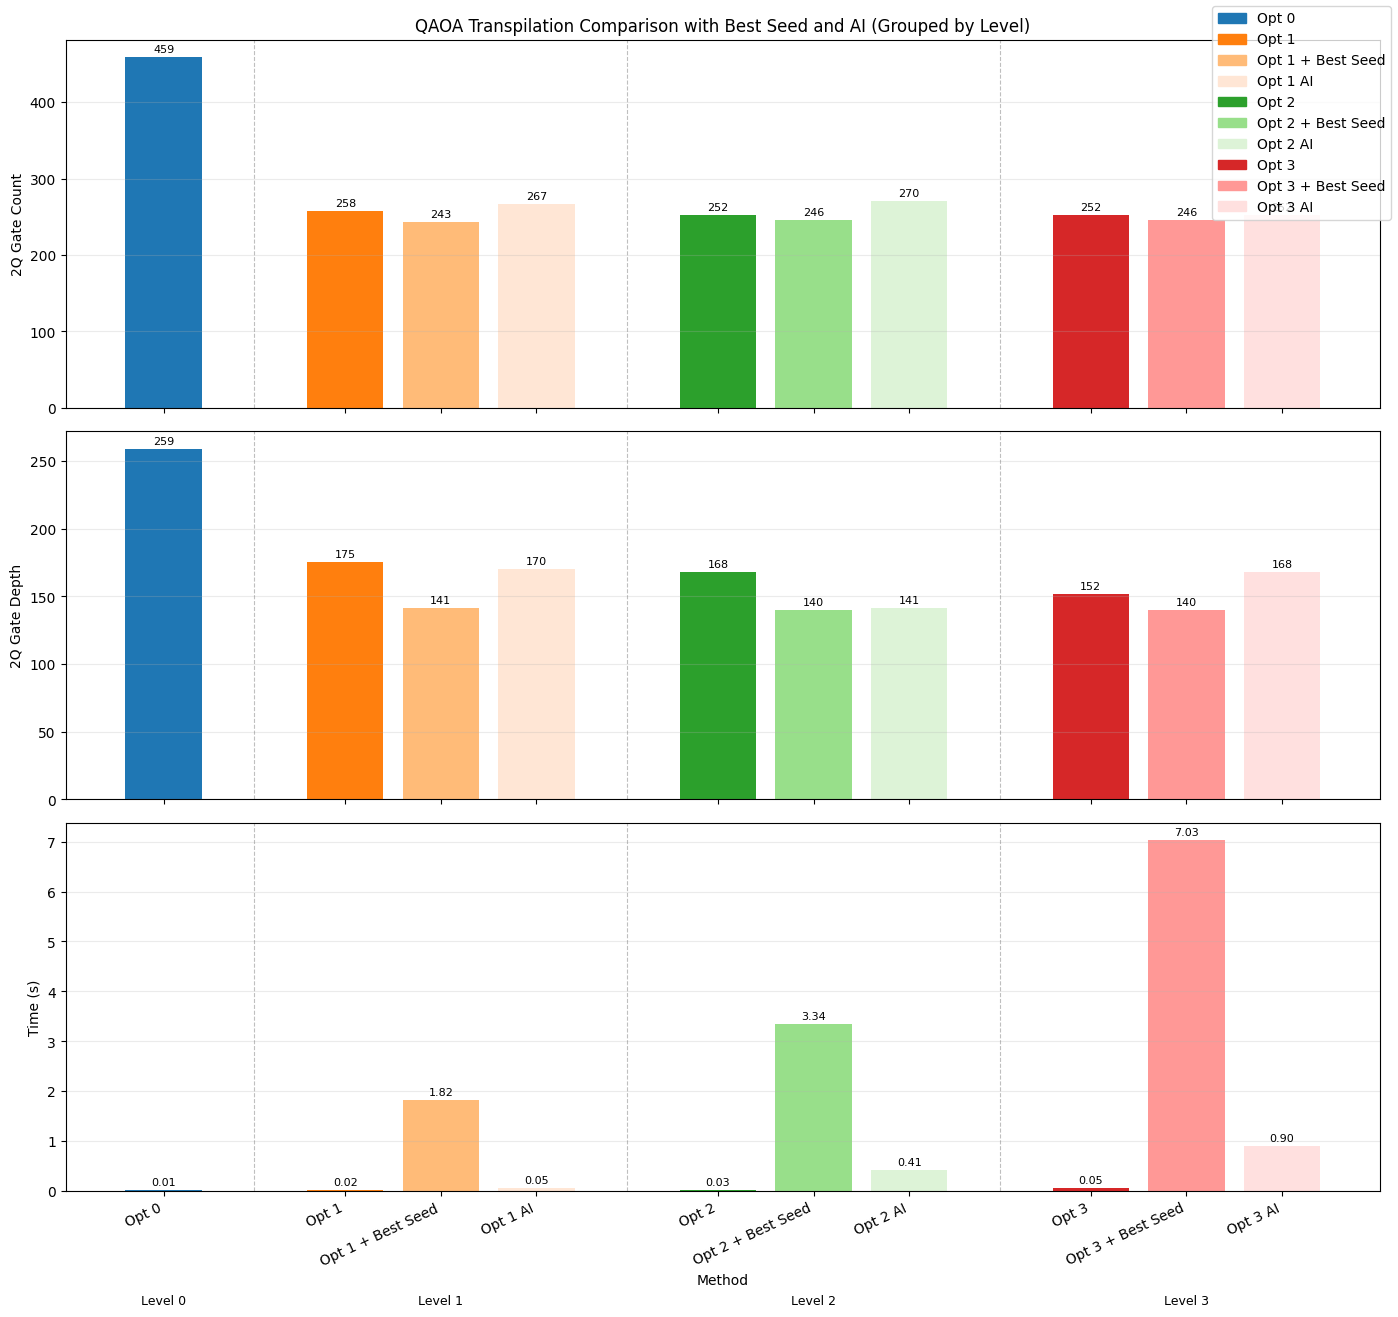

In [37]:
# Extract AI transpiler metrics and plot full comparison in 3 panels (grouped by level)
import matplotlib.pyplot as plt

# Metrics for AI transpiler circuits
metrics_ai_opt_lvl_1 = extract_circuit_metrics(transpiled_qaoa_ai_opt_lvl_1)
metrics_ai_opt_lvl_2 = extract_circuit_metrics(transpiled_qaoa_ai_opt_lvl_2)
metrics_ai_opt_lvl_3 = extract_circuit_metrics(transpiled_qaoa_ai_opt_lvl_3)

# Build grouped layout by optimization level
groups = [
    [('Opt 0', metrics_opt_lvl_0, t_opt_lvl_0, '#1f77b4')],
    [('Opt 1', metrics_opt_lvl_1, t_opt_lvl_1, '#ff7f0e'), ('Opt 1 + Best Seed', metrics_opt_lvl_1_optimized_seed, t_opt_lvl_1_optimized_seed, '#ffbb78'), ('Opt 1 AI', metrics_ai_opt_lvl_1, t_ai_opt_lvl_1, '#ffe6d5')],
    [('Opt 2', metrics_opt_lvl_2, t_opt_lvl_2, '#2ca02c'), ('Opt 2 + Best Seed', metrics_opt_lvl_2_optimized_seed, t_opt_lvl_2_optimized_seed, '#98df8a'), ('Opt 2 AI', metrics_ai_opt_lvl_2, t_ai_opt_lvl_2, '#ddf3d7')],
    [('Opt 3', metrics_opt_lvl_3, t_opt_lvl_3, '#d62728'), ('Opt 3 + Best Seed', metrics_opt_lvl_3_optimized_seed, t_opt_lvl_3_optimized_seed, '#ff9896'), ('Opt 3 AI', metrics_ai_opt_lvl_3, t_ai_opt_lvl_3, '#ffe0df')],
]

x_positions = []
method_labels = []
method_colors = []
twoq_counts = []
twoq_depths = []
transpile_times = []
group_centers = []
group_boundaries = []

current_x = 0.0
within_group_step = 1.0
group_gap = 0.9

for group in groups:
    start_x = current_x
    for label, metrics, t_val, color in group:
        x_positions.append(current_x)
        method_labels.append(label)
        method_colors.append(color)
        twoq_counts.append(metrics['two_qubit_gates'])
        twoq_depths.append(metrics['two_qubit_gate_depth'])
        transpile_times.append(t_val)
        current_x += within_group_step
    end_x = current_x - within_group_step
    group_centers.append((start_x + end_x) / 2)
    group_boundaries.append(current_x - within_group_step / 2 + group_gap / 2)
    current_x += group_gap

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

series = [twoq_counts, twoq_depths, transpile_times]
ylabels = ['2Q Gate Count', '2Q Gate Depth', 'Time (s)']
label_formatters = [
    lambda v: str(int(v)),
    lambda v: str(int(v)),
    lambda v: f'{v:.2f}',
]

for ax, values, ylabel, fmt in zip(axes, series, ylabels, label_formatters):
    bars = ax.bar(x_positions, values, color=method_colors, width=0.8)
    ax.set_ylabel(ylabel)
    ax.bar_label(bars, labels=[fmt(v) for v in values], padding=2, fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    for boundary in group_boundaries[:-1]:
        ax.axvline(boundary, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

axes[0].set_title('QAOA Transpilation Comparison with Best Seed and AI (Grouped by Level)')
axes[2].set_xlabel('Method')
axes[2].set_xticks(x_positions)
axes[2].set_xticklabels(method_labels, rotation=25, ha='right')

for i, center in enumerate(group_centers):
    axes[2].text(center, -0.28, f'Level {i}', transform=axes[2].get_xaxis_transform(), ha='center', va='top', fontsize=9)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=l) for c, l in zip(method_colors, method_labels)]
fig.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()

## Q-CTRL Performance Management Function

In [38]:
from qiskit_ibm_catalog import QiskitFunctionsCatalog

catalog = QiskitFunctionsCatalog()
perf_mgmt = catalog.load("q-ctrl/performance-management")

In [39]:
pubs = [(qaoa_circuit, [0.1]*len(qaoa_circuit.parameters))]

qctrl_sampler_job = perf_mgmt.run(
    primitive="sampler",
    pubs=pubs,
    backend_name="ibm_pittsburgh",
)

In [40]:
qctrl_sampler_job.status()

'QUEUED'

In [42]:
from qiskit_ibm_runtime import QiskitRuntimeService
from utils import extract_circuit_metrics

service = QiskitRuntimeService()
job = service.job(qctrl_sampler_job.runtime_jobs()[0])
circuit = job.inputs.get('pubs')[0][0]
print(extract_circuit_metrics(circuit))

{'count_ops': OrderedDict({'rz': 676, 'delay': 429, 'rx': 351, 'x': 180, 'cz': 135, 'rzz': 58, 'measure': 10, 'barrier': 1}), 'depth': 354, 'two_qubit_gates': 193, 'two_qubit_gate_depth': 106}


/Users/junye/GitHub/HJY/qaoa-transpilation/.venv/lib/python3.13/site-packages/qiskit/qpy/interface.py:376: UserWarning: The qiskit version used to generate the provided QPY file, 2.2.1, is newer than the current qiskit version 2.2.0. This may result in an error if the QPY file uses instructions not present in this current qiskit version
  warnings.warn(


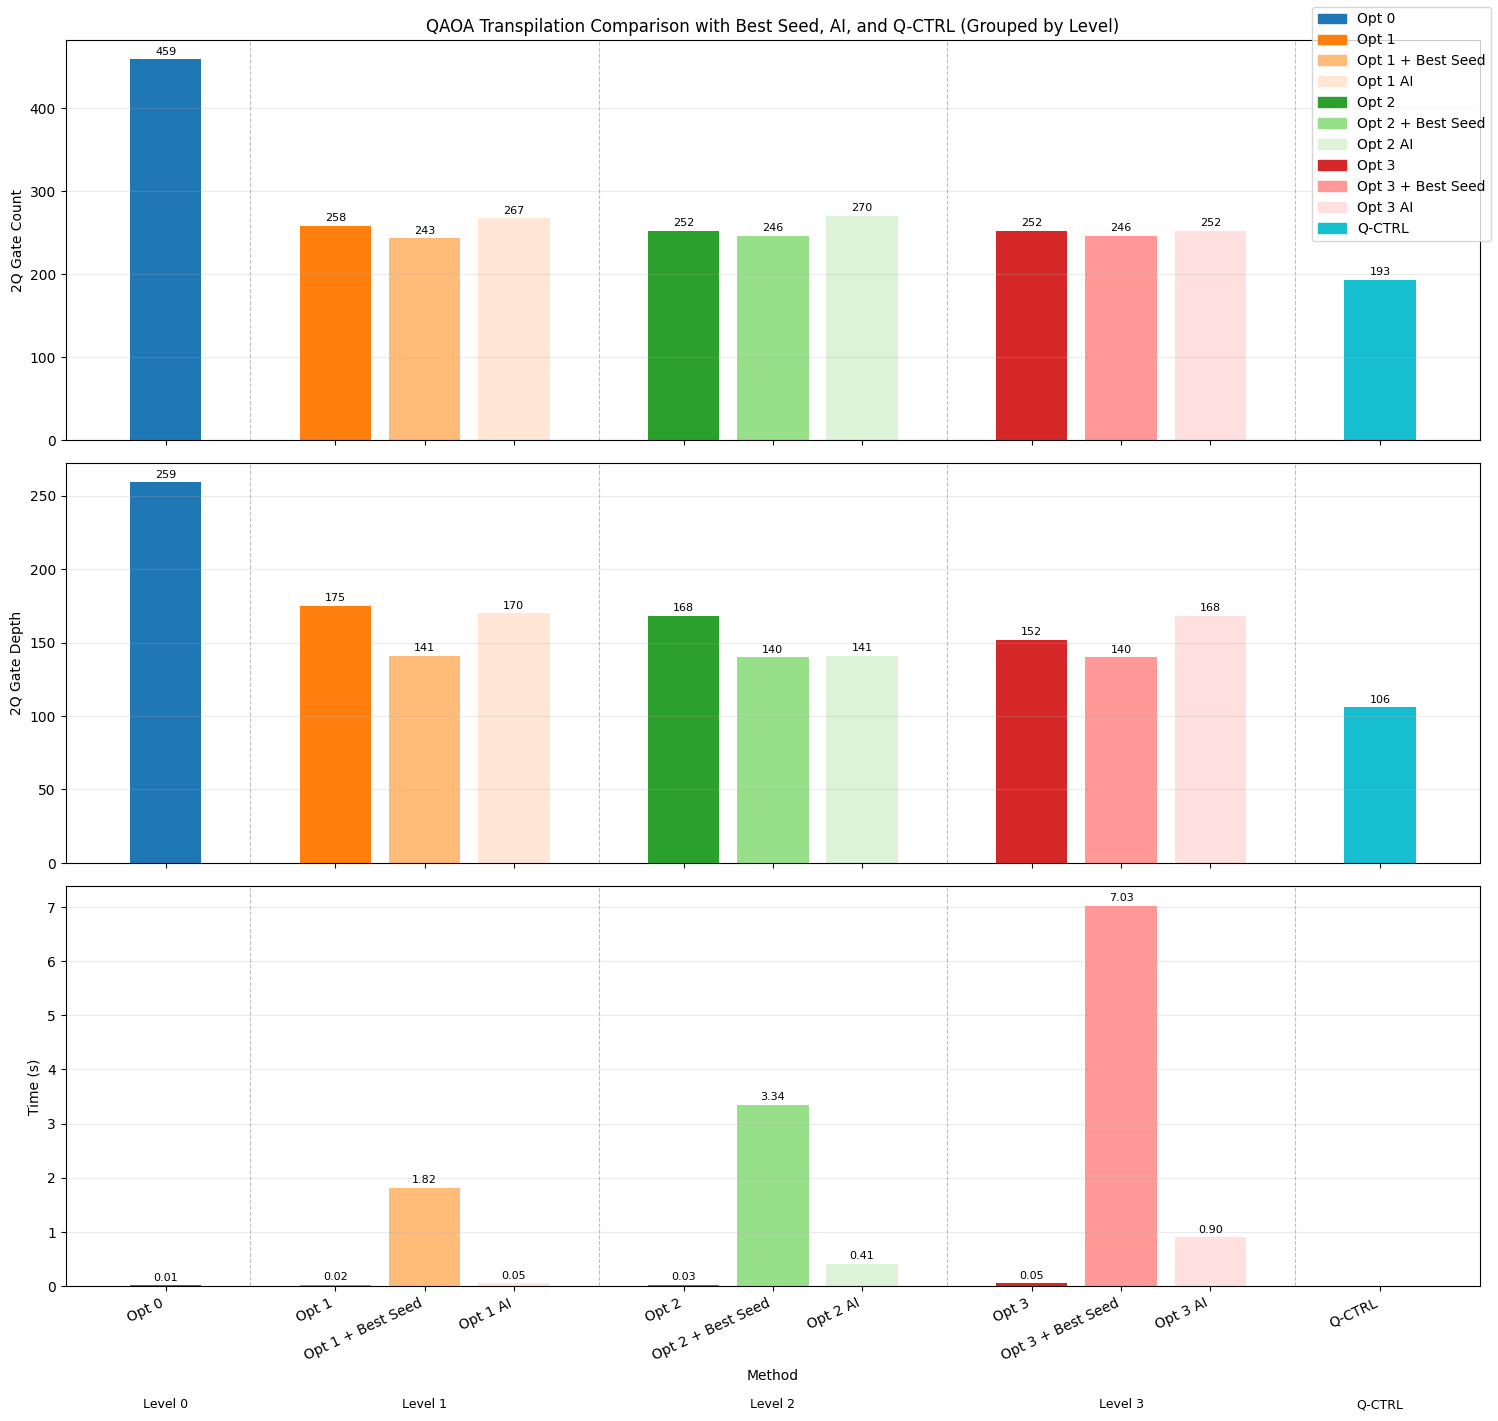

Q-CTRL metrics: {'count_ops': OrderedDict({'rz': 676, 'delay': 429, 'rx': 351, 'x': 180, 'cz': 135, 'rzz': 58, 'measure': 10, 'barrier': 1}), 'depth': 354, 'two_qubit_gates': 193, 'two_qubit_gate_depth': 106}
Q-CTRL runtime (s): nan


In [43]:
# Plot full comparison in 3 panels, including Q-CTRL (grouped by level)
import matplotlib.pyplot as plt
from datetime import datetime

# AI transpiler metrics (recompute here to keep this cell self-contained)
metrics_ai_opt_lvl_1 = extract_circuit_metrics(transpiled_qaoa_ai_opt_lvl_1)
metrics_ai_opt_lvl_2 = extract_circuit_metrics(transpiled_qaoa_ai_opt_lvl_2)
metrics_ai_opt_lvl_3 = extract_circuit_metrics(transpiled_qaoa_ai_opt_lvl_3)

# Extract Q-CTRL output circuit and metrics
service = QiskitRuntimeService()
qctrl_runtime_job_id = qctrl_sampler_job.runtime_jobs()[0]
qctrl_runtime_job = service.job(qctrl_runtime_job_id)
qctrl_circuit = qctrl_runtime_job.inputs.get('pubs')[0][0]
metrics_qctrl = extract_circuit_metrics(qctrl_circuit)

# Estimate Q-CTRL runtime duration in seconds from job timestamps
if getattr(qctrl_runtime_job, 'creation_date', None) and getattr(qctrl_runtime_job, 'completion_date', None):
    start = qctrl_runtime_job.creation_date
    end = qctrl_runtime_job.completion_date
    if isinstance(start, str):
        start = datetime.fromisoformat(start.replace('Z', '+00:00'))
    if isinstance(end, str):
        end = datetime.fromisoformat(end.replace('Z', '+00:00'))
    qctrl_time_s = (end - start).total_seconds()
else:
    qctrl_time_s = float('nan')

# Group by optimization level, then append Q-CTRL
groups = [
    [('Opt 0', metrics_opt_lvl_0, t_opt_lvl_0, '#1f77b4')],
    [('Opt 1', metrics_opt_lvl_1, t_opt_lvl_1, '#ff7f0e'), ('Opt 1 + Best Seed', metrics_opt_lvl_1_optimized_seed, t_opt_lvl_1_optimized_seed, '#ffbb78'), ('Opt 1 AI', metrics_ai_opt_lvl_1, t_ai_opt_lvl_1, '#ffe6d5')],
    [('Opt 2', metrics_opt_lvl_2, t_opt_lvl_2, '#2ca02c'), ('Opt 2 + Best Seed', metrics_opt_lvl_2_optimized_seed, t_opt_lvl_2_optimized_seed, '#98df8a'), ('Opt 2 AI', metrics_ai_opt_lvl_2, t_ai_opt_lvl_2, '#ddf3d7')],
    [('Opt 3', metrics_opt_lvl_3, t_opt_lvl_3, '#d62728'), ('Opt 3 + Best Seed', metrics_opt_lvl_3_optimized_seed, t_opt_lvl_3_optimized_seed, '#ff9896'), ('Opt 3 AI', metrics_ai_opt_lvl_3, t_ai_opt_lvl_3, '#ffe0df')],
]

x_positions = []
method_labels = []
method_colors = []
twoq_counts = []
twoq_depths = []
transpile_times = []
group_centers = []
group_boundaries = []

current_x = 0.0
within_group_step = 1.0
group_gap = 0.9

for group in groups:
    start_x = current_x
    for label, metrics, t_val, color in group:
        x_positions.append(current_x)
        method_labels.append(label)
        method_colors.append(color)
        twoq_counts.append(metrics['two_qubit_gates'])
        twoq_depths.append(metrics['two_qubit_gate_depth'])
        transpile_times.append(t_val)
        current_x += within_group_step
    end_x = current_x - within_group_step
    group_centers.append((start_x + end_x) / 2)
    group_boundaries.append(current_x - within_group_step / 2 + group_gap / 2)
    current_x += group_gap

# Add Q-CTRL as a final separate group
x_positions.append(current_x)
method_labels.append('Q-CTRL')
method_colors.append('#17becf')
twoq_counts.append(metrics_qctrl['two_qubit_gates'])
twoq_depths.append(metrics_qctrl['two_qubit_gate_depth'])
transpile_times.append(qctrl_time_s)
group_centers.append(current_x)

fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=True)

series = [twoq_counts, twoq_depths, transpile_times]
ylabels = ['2Q Gate Count', '2Q Gate Depth', 'Time (s)']
label_formatters = [
    lambda v: str(int(v)),
    lambda v: str(int(v)),
    lambda v: 'NA' if (isinstance(v, float) and (v != v)) else f'{v:.2f}',
]

for ax, values, ylabel, fmt in zip(axes, series, ylabels, label_formatters):
    bars = ax.bar(x_positions, values, color=method_colors, width=0.8)
    ax.set_ylabel(ylabel)
    ax.bar_label(bars, labels=[fmt(v) for v in values], padding=2, fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    for boundary in group_boundaries:
        ax.axvline(boundary, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

axes[0].set_title('QAOA Transpilation Comparison with Best Seed, AI, and Q-CTRL (Grouped by Level)')
axes[2].set_xlabel('Method')
axes[2].set_xticks(x_positions)
axes[2].set_xticklabels(method_labels, rotation=25, ha='right')

for i, center in enumerate(group_centers[:-1]):
    axes[2].text(center, -0.28, f'Level {i}', transform=axes[2].get_xaxis_transform(), ha='center', va='top', fontsize=9)
axes[2].text(group_centers[-1], -0.28, 'Q-CTRL', transform=axes[2].get_xaxis_transform(), ha='center', va='top', fontsize=9)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=l) for c, l in zip(method_colors, method_labels)]
fig.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()

print('Q-CTRL metrics:', metrics_qctrl)
print('Q-CTRL runtime (s):', qctrl_time_s)

## Advanced QAOA Transpilation

In [44]:
metrics_advanced_10q = {
        'two_qubit_gates': 333,
        'two_qubit_gate_depth': 78,
        'time': 0.00884795
}

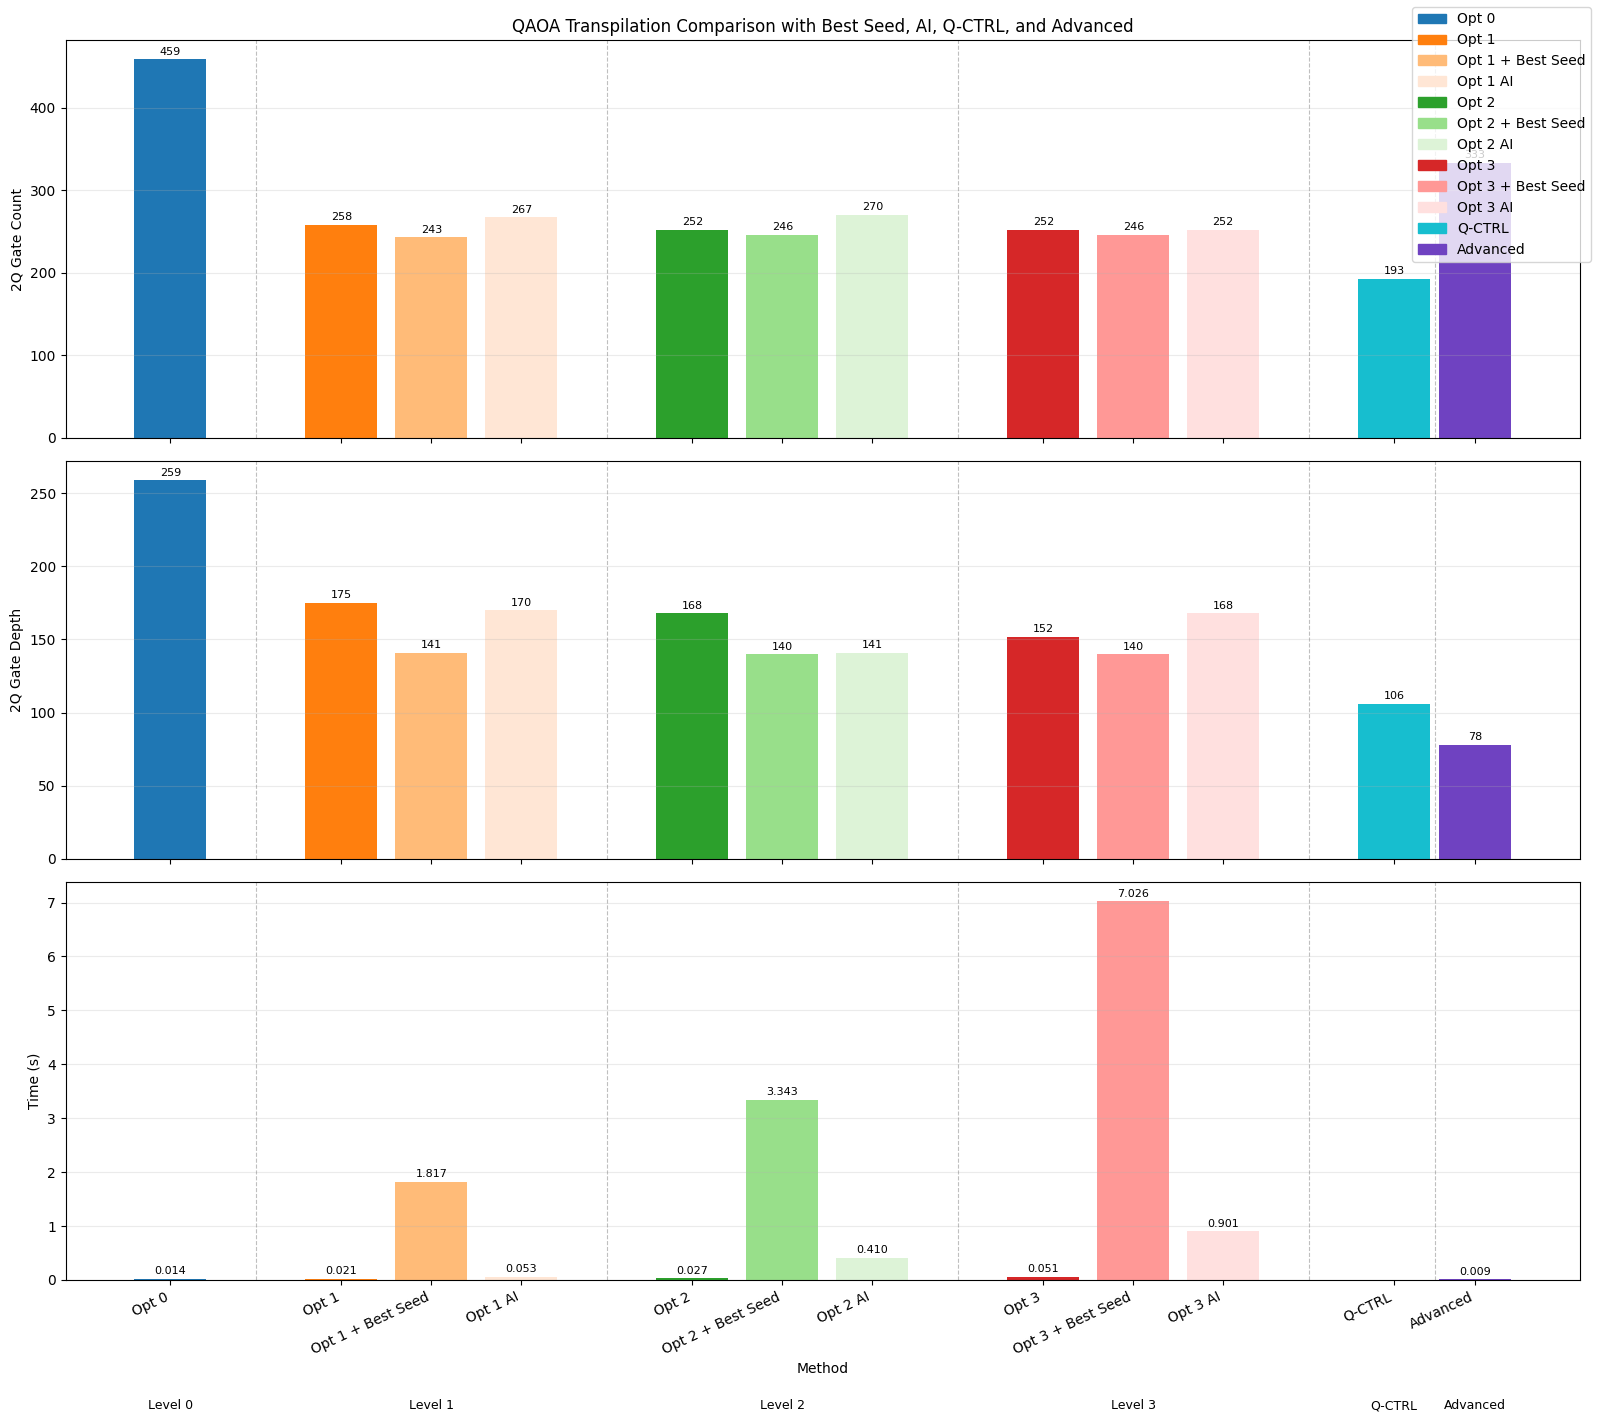

Advanced metrics: {'two_qubit_gates': 333, 'two_qubit_gate_depth': 78, 'time': 0.00884795}


In [45]:
# Plot full comparison in 3 panels, including advanced transpilation result
import matplotlib.pyplot as plt
from datetime import datetime

metrics_ai_opt_lvl_1 = extract_circuit_metrics(transpiled_qaoa_ai_opt_lvl_1)
metrics_ai_opt_lvl_2 = extract_circuit_metrics(transpiled_qaoa_ai_opt_lvl_2)
metrics_ai_opt_lvl_3 = extract_circuit_metrics(transpiled_qaoa_ai_opt_lvl_3)

if 'metrics_qctrl' not in globals() or 'qctrl_time_s' not in globals():
    service = QiskitRuntimeService()
    qctrl_runtime_job = service.job(qctrl_sampler_job.runtime_jobs()[0])
    qctrl_circuit = qctrl_runtime_job.inputs.get('pubs')[0][0]
    metrics_qctrl = extract_circuit_metrics(qctrl_circuit)
    if getattr(qctrl_runtime_job, 'creation_date', None) and getattr(qctrl_runtime_job, 'completion_date', None):
        start = qctrl_runtime_job.creation_date
        end = qctrl_runtime_job.completion_date
        if isinstance(start, str):
            start = datetime.fromisoformat(start.replace('Z', '+00:00'))
        if isinstance(end, str):
            end = datetime.fromisoformat(end.replace('Z', '+00:00'))
        qctrl_time_s = (end - start).total_seconds()
    else:
        qctrl_time_s = float('nan')

groups = [
    [('Opt 0', metrics_opt_lvl_0, t_opt_lvl_0, '#1f77b4')],
    [('Opt 1', metrics_opt_lvl_1, t_opt_lvl_1, '#ff7f0e'), ('Opt 1 + Best Seed', metrics_opt_lvl_1_optimized_seed, t_opt_lvl_1_optimized_seed, '#ffbb78'), ('Opt 1 AI', metrics_ai_opt_lvl_1, t_ai_opt_lvl_1, '#ffe6d5')],
    [('Opt 2', metrics_opt_lvl_2, t_opt_lvl_2, '#2ca02c'), ('Opt 2 + Best Seed', metrics_opt_lvl_2_optimized_seed, t_opt_lvl_2_optimized_seed, '#98df8a'), ('Opt 2 AI', metrics_ai_opt_lvl_2, t_ai_opt_lvl_2, '#ddf3d7')],
    [('Opt 3', metrics_opt_lvl_3, t_opt_lvl_3, '#d62728'), ('Opt 3 + Best Seed', metrics_opt_lvl_3_optimized_seed, t_opt_lvl_3_optimized_seed, '#ff9896'), ('Opt 3 AI', metrics_ai_opt_lvl_3, t_ai_opt_lvl_3, '#ffe0df')],
]

x_positions = []
method_labels = []
method_colors = []
twoq_counts = []
twoq_depths = []
transpile_times = []
group_centers = []
group_boundaries = []

current_x = 0.0
within_group_step = 1.0
group_gap = 0.9

for group in groups:
    start_x = current_x
    for label, metrics, t_val, color in group:
        x_positions.append(current_x)
        method_labels.append(label)
        method_colors.append(color)
        twoq_counts.append(metrics['two_qubit_gates'])
        twoq_depths.append(metrics['two_qubit_gate_depth'])
        transpile_times.append(t_val)
        current_x += within_group_step
    end_x = current_x - within_group_step
    group_centers.append((start_x + end_x) / 2)
    group_boundaries.append(current_x - within_group_step / 2 + group_gap / 2)
    current_x += group_gap

x_positions.append(current_x)
method_labels.append('Q-CTRL')
method_colors.append('#17becf')
twoq_counts.append(metrics_qctrl['two_qubit_gates'])
twoq_depths.append(metrics_qctrl['two_qubit_gate_depth'])
transpile_times.append(qctrl_time_s)
group_centers.append(current_x)
group_boundaries.append(current_x + group_gap / 2)
current_x += group_gap

x_positions.append(current_x)
method_labels.append('Advanced')
method_colors.append('#6f42c1')
twoq_counts.append(metrics_advanced_10q['two_qubit_gates'])
twoq_depths.append(metrics_advanced_10q['two_qubit_gate_depth'])
transpile_times.append(metrics_advanced_10q['time'])
group_centers.append(current_x)

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
series = [twoq_counts, twoq_depths, transpile_times]
ylabels = ['2Q Gate Count', '2Q Gate Depth', 'Time (s)']
label_formatters = [
    lambda v: str(int(v)),
    lambda v: str(int(v)),
    lambda v: 'NA' if (isinstance(v, float) and (v != v)) else f'{v:.3f}',
]

for ax, values, ylabel, fmt in zip(axes, series, ylabels, label_formatters):
    bars = ax.bar(x_positions, values, color=method_colors, width=0.8)
    ax.set_ylabel(ylabel)
    ax.bar_label(bars, labels=[fmt(v) for v in values], padding=2, fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    for boundary in group_boundaries:
        ax.axvline(boundary, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

axes[0].set_title('QAOA Transpilation Comparison with Best Seed, AI, Q-CTRL, and Advanced')
axes[2].set_xlabel('Method')
axes[2].set_xticks(x_positions)
axes[2].set_xticklabels(method_labels, rotation=25, ha='right')

for i, center in enumerate(group_centers[:4]):
    axes[2].text(center, -0.30, f'Level {i}', transform=axes[2].get_xaxis_transform(), ha='center', va='top', fontsize=9)
axes[2].text(group_centers[4], -0.30, 'Q-CTRL', transform=axes[2].get_xaxis_transform(), ha='center', va='top', fontsize=9)
axes[2].text(group_centers[5], -0.30, 'Advanced', transform=axes[2].get_xaxis_transform(), ha='center', va='top', fontsize=9)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=l) for c, l in zip(method_colors, method_labels)]
fig.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()

print('Advanced metrics:', metrics_advanced_10q)